## Down Syndrome Visualizations

### Common Imports

In [1]:
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

### Load Data

In [3]:
df = pkl.load(open("../../../data/processed/down_syndrome/cleaned_df.pkl", "rb"))

### Univariate Visualizations

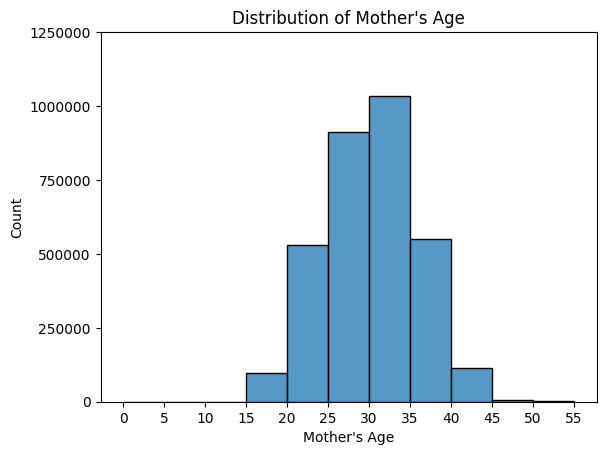

In [ ]:
mothers_age_value_counts = df["mothers_single_year_age"].value_counts()

mothers_age_bar_ax = sns.histplot(
    x=mothers_age_value_counts.index,
    weights=mothers_age_value_counts.values,
    bins=range(0, 60, 5),
)
mothers_age_bar_ax.set_title("Distribution of Mother's Age")
mothers_age_bar_ax.set_xlabel("Mother's Age")
mothers_age_bar_ax.set_ylabel("Count")
mothers_age_bar_ax.set_xticks(range(0, 60, 5))
mothers_age_bar_ax.set_yticks(
    range(0, 1250001, 250000), labels=range(0, 1250001, 250000)
)
plt.show()

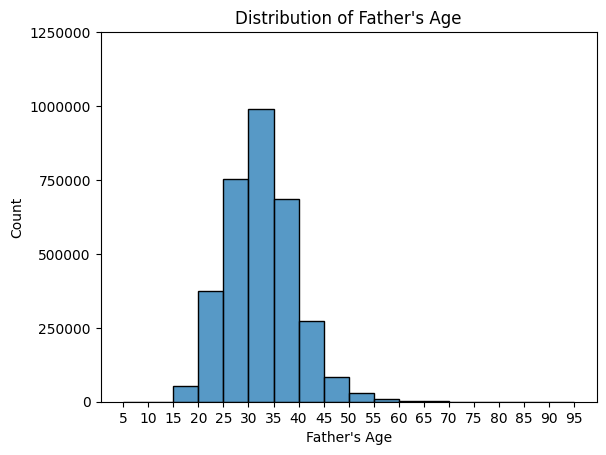

In [ ]:
fathers_age_value_counts = df["fathers_combined_age"].value_counts()

fathers_age_bar_ax = sns.histplot(
    x=fathers_age_value_counts.index,
    weights=fathers_age_value_counts.values,
    bins=range(5, 99, 5),
)
fathers_age_bar_ax.set_title("Distribution of Father's Age")
fathers_age_bar_ax.set_xlabel("Father's Age")
fathers_age_bar_ax.set_ylabel("Count")
fathers_age_bar_ax.set_xticks(range(5, 99, 5))
fathers_age_bar_ax.set_yticks(
    range(0, 1250001, 250000), labels=range(0, 1250001, 250000)
)
plt.show()

### Bivariate Visualizations

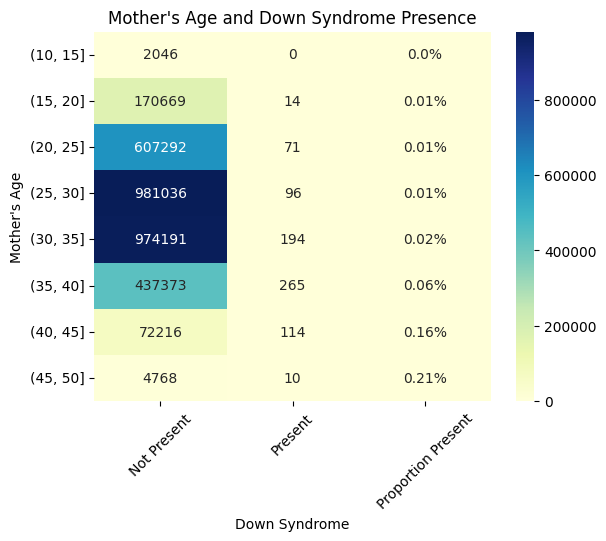

In [8]:
mothers_age_cross_tab = pd.crosstab(
    pd.cut(df["mothers_single_year_age"], bins=range(0, 61, 5)), df["target"]
)
mothers_age_cross_tab["proportion"] = (
    round(
        mothers_age_cross_tab[1].astype(float)
        / (
            mothers_age_cross_tab[0].astype(float)
            + mothers_age_cross_tab[1].astype(float)
        ),
        4,
    )
    * 100
)

annotation_matrix = mothers_age_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(mothers_age_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

mothers_age_cross_tab_ax = sns.heatmap(
    mothers_age_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
mothers_age_cross_tab_ax.set_title("Mother's Age and Down Syndrome Presence")
mothers_age_cross_tab_ax.set_xlabel("Down Syndrome")
mothers_age_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Proportion Present"], rotation=45
)
mothers_age_cross_tab_ax.set_ylabel("Mother's Age")
plt.show()

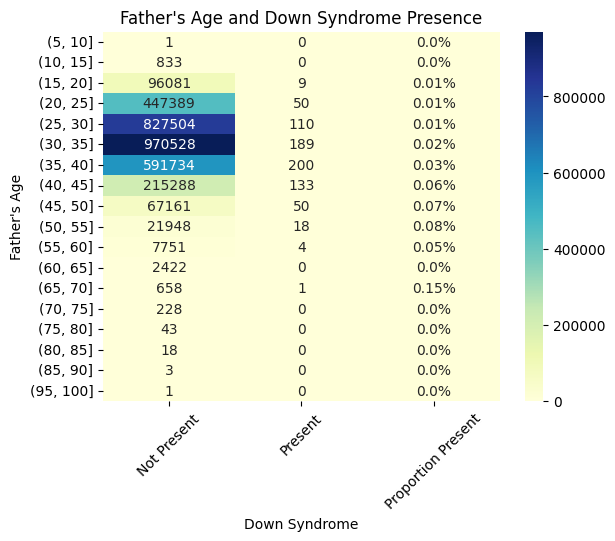

In [ ]:
fathers_age_cross_tab = pd.crosstab(
    pd.cut(
        df["fathers_combined_age"],
        bins=range(0, 101, 5),
    ),
    df["target"],
)
fathers_age_cross_tab["proportion"] = (
    round(
        fathers_age_cross_tab[1].astype(float)
        / (fathers_age_cross_tab[0] + fathers_age_cross_tab[1]),
        4,
    )
    * 100
)

annotation_matrix = fathers_age_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(fathers_age_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

fathers_age_cross_tab_ax = sns.heatmap(
    fathers_age_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
fathers_age_cross_tab_ax.set_title("Father's Age and Down Syndrome Presence")
fathers_age_cross_tab_ax.set_xlabel("Down Syndrome")
fathers_age_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Proportion Present"], rotation=45
)
fathers_age_cross_tab_ax.set_ylabel("Father's Age")

plt.show()

### Multivariate Visualizations

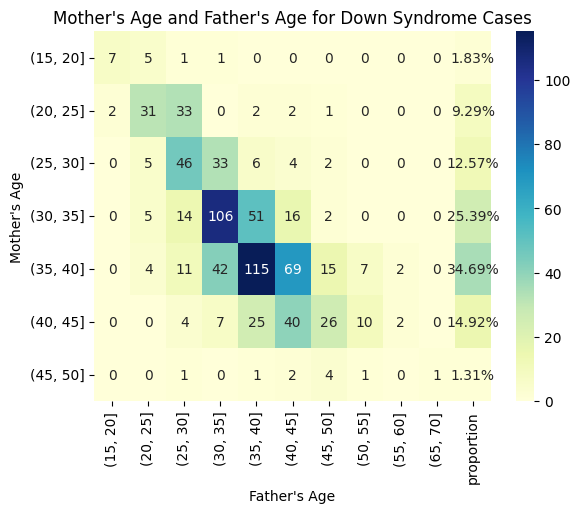

In [ ]:
age_cross_tab = pd.crosstab(
    pd.cut(df[df["target"] == 1]["mothers_single_year_age"], bins=range(0, 61, 5)),
    pd.cut(df[df["target"] == 1]["fathers_combined_age"], bins=range(0, 101, 5)),
)
age_cross_tab["proportion"] = (
    round(
        age_cross_tab.sum(axis=1).astype(float) / age_cross_tab.sum().sum(),
        4,
    )
    * 100
)

annotation_matrix = age_cross_tab.copy()
annotation_matrix["proportion"] = round(age_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

age_cross_tab_ax = sns.heatmap(
    age_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
age_cross_tab_ax.set_title("Mother's Age and Father's Age for Down Syndrome Cases")
age_cross_tab_ax.set_xlabel("Father's Age")
age_cross_tab_ax.set_ylabel("Mother's Age")

plt.show()

### Conclusion

Our cleaned data reflects the hypothesis that rates of Down syndrome increase with parents' age.